# Прогнозирование биологической активности химических соединений: научный отчёт

## 1. Введение и постановка задачи

### 1.1. Описание проблемы

Работа выполняется в рамках задачи прогнозирования биологической активности химических соединений по их структурным дескрипторам. Подобные модели применяются на ранней стадии разработки лекарственных препаратов для предварительного отбора веществ перед дорогостоящими лабораторными испытаниями.

### 1.2. Цель работы

По обучающей выборке из 751 соединения требуется построить модель, предсказывающую для каждого соединения тестовой выборки (250 объектов) три величины:

- **IC50** - концентрация половинного подавления вируса (мМ). Чем меньше значение, тем выше противовирусная активность.
- **CC50** - концентрация половинной цитотоксичности по отношению к клеткам (мМ). Чем больше значение, тем безопаснее вещество.
- **SI** - индекс селективности, равный отношению CC50 / IC50. Чем больше значение, тем избирательнее действие.

Каждое соединение описано вектором из 210 числовых признаков (молекулярных дескрипторов).

### 1.3. Метрика качества

Решение оценивается по метрике RMSE (корень из среднеквадратичной ошибки), усреднённой по трём целевым переменным:

$$
\text{score} = \frac{1}{3}\bigl(\text{RMSE}(\text{IC50}) + \text{RMSE}(\text{CC50}) + \text{RMSE}(\text{SI})\bigr).
$$

Чем меньше значение, тем лучше качество модели.

### 1.4. Структура отчёта

Отчёт построен как единый sklearn-конвейер от загрузки данных до формирования итогового файла предсказаний и охватывает полный цикл машинного обучения:

1. Введение и постановка задачи (раздел 1).
2. Загрузка библиотек и данных (раздел 2).
3. Разведочный анализ данных (раздел 3).
4. Предобработка данных (раздел 4).
5. Базовая модель: гребневая регрессия (раздел 5).
6. Основная модель: градиентный бустинг с устойчивой функцией потерь (раздел 6).
7. Расширение ансамбля: гауссовский процесс и подбор весов смешивания (раздел 7).
8. Калибровка отсечения предсказаний (раздел 8).
9. Анализ важности признаков (раздел 9).
10. Итоги и формирование файла предсказаний (раздел 10).

Все компоненты конвейера (трансформеры предобработки, базовые модели, бэггинг-обёртка) определяются один раз и далее используются на каждом из последующих этапов без дублирования кода.

## 2. Загрузка библиотек и данных

### 2.1. Используемые библиотеки

В качестве инструментария используются стандартные библиотеки экосистемы Python: `pandas` и `numpy` для работы с табличными структурами, `matplotlib` и `seaborn` для визуализации, `scipy.stats` для статистических тестов, `sklearn` для предварительной обработки, валидации и базовых регрессионных моделей. Дополнительно подключаются библиотеки градиентного бустинга `catboost` и `lightgbm`. Все источники случайности зафиксированы параметром `SEED = 42`, что обеспечивает воспроизводимость результатов.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import nnls
from scipy.stats import loguniform, randint

from sklearn.base import BaseEstimator, RegressorMixin, TransformerMixin
from sklearn.cluster import AgglomerativeClustering
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, pairwise_distances
from sklearn.model_selection import GroupKFold, KFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import lightgbm as lgb
from catboost import CatBoostRegressor

SEED = 42
np.random.seed(SEED)

DATA_DIR = Path('data')
ID_COL = 'index'
TARGETS = ['IC50, mM', 'CC50, mM', 'SI']

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

sns.set_style('whitegrid')
print('Импорты выполнены. SEED =', SEED)


Импорты выполнены. SEED = 42


### 2.2. Загрузка обучающей и тестовой выборок

Из обучающей выборки выделяются матрица признаков $X_{\text{train}}$ и три вектора целевых переменных. Из тестовой выборки выделяется только матрица признаков $X_{\text{test}}$. Проверяется согласованность набора признаков и подсчитывается число пропущенных значений.

In [2]:
train = pd.read_csv(DATA_DIR / 'train.csv')
test = pd.read_csv(DATA_DIR / 'test.csv')

feature_cols = [c for c in train.columns if c not in TARGETS + [ID_COL]]
X_train = train[feature_cols].to_numpy(dtype=float)
X_test = test[feature_cols].to_numpy(dtype=float)
y_train = {t: train[t].to_numpy(dtype=float) for t in TARGETS}

print('Размер обучающей выборки:', train.shape)
print('Размер тестовой выборки: ', test.shape)
print('Число признаков:', len(feature_cols))
print('Списки признаков совпадают:', feature_cols == [c for c in test.columns if c != ID_COL])
print()
print('Пропусков в X_train:', int(np.isnan(X_train).sum()))
print('Пропусков в X_test: ', int(np.isnan(X_test).sum()))


Размер обучающей выборки: (751, 214)
Размер тестовой выборки:  (250, 211)
Число признаков: 210
Списки признаков совпадают: True

Пропусков в X_train: 24
Пропусков в X_test:  12


Обучающая выборка содержит 751 наблюдение, тестовая - 250. Число признаков равно 210, их состав в обеих выборках совпадает. Доля пропущенных значений мала (менее 0.02 % от общего числа ячеек).

Соотношение размера выборки к числу признаков составляет $N / p \approx 3.6$. На 210 признаках обучаемая регрессионная модель на выборке такого объёма легко переобучается: число параметров сопоставимо с числом наблюдений. Из этого факта вытекают первые два требования к будущим моделям: необходимость регуляризации и применение усреднения нескольких моделей (бутстреп-агрегирование).

## 3. Разведочный анализ данных

### 3.1. Анализ распределения целевых переменных

Форма распределения целевых переменных оказывает прямое влияние на выбор функции потерь, стратегии валидации и класса применимых моделей. Для каждой из трёх целевых переменных рассчитываются описательные статистики (среднее, медиана, квантили уровня 0.9 и 0.99, максимум, коэффициент асимметрии) и строятся гистограмма в логарифмической шкале по оси Y и диаграмма размаха (boxplot).

Описательная статистика целевых переменных:
            mean     50%      90%      99%       max   skew
IC50, mM  204.54   44.07   735.14  1334.27   4095.19   3.79
CC50, mM  577.43  376.58  1269.25  3162.01   4538.98   2.06
SI         89.15    4.00    50.85  1281.25  15620.60  15.63


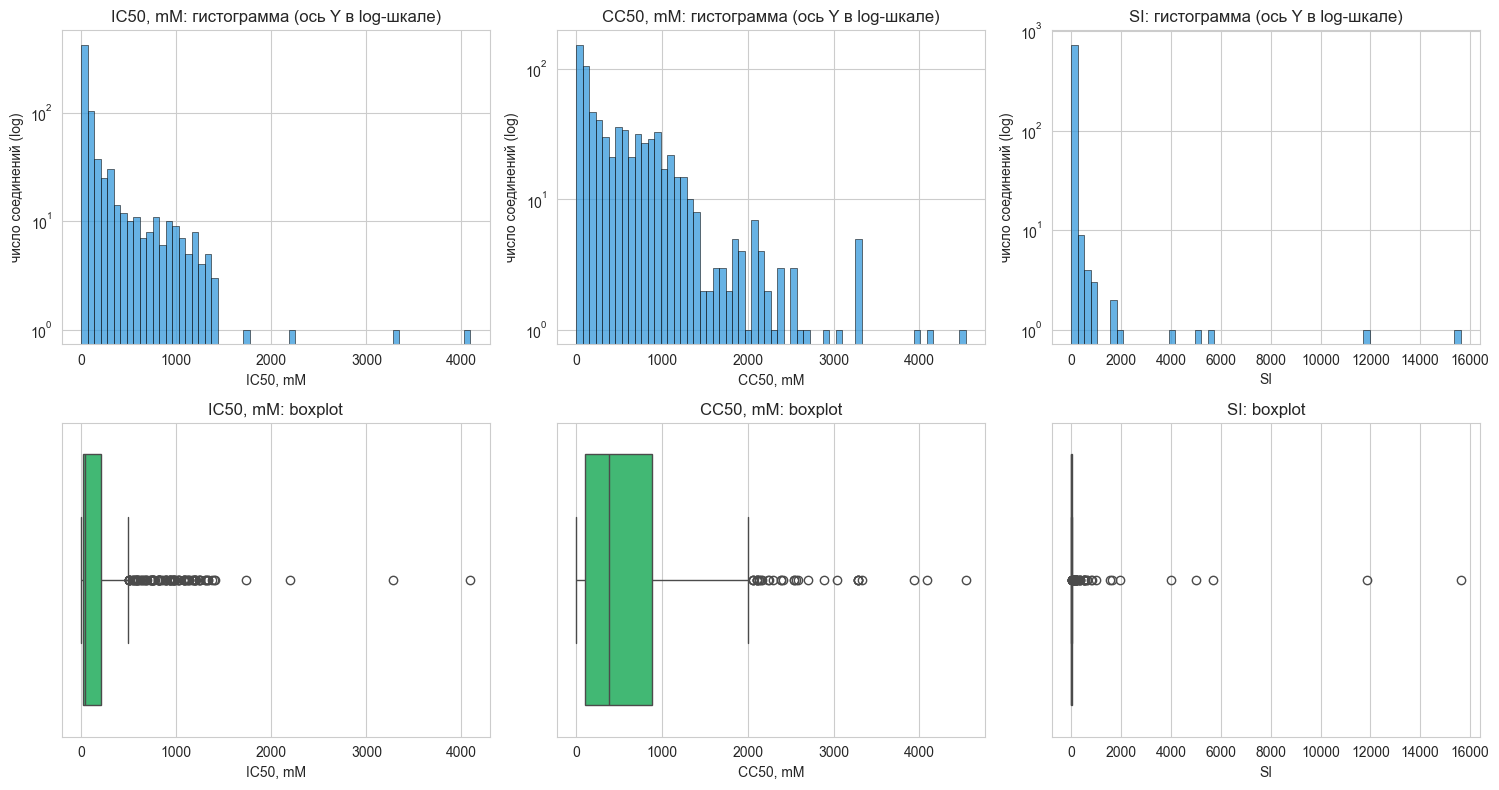

In [3]:
desc = train[TARGETS].describe(percentiles=[0.5, 0.9, 0.99]).T
desc['skew'] = train[TARGETS].skew().values
print('Описательная статистика целевых переменных:')
print(desc[['mean', '50%', '90%', '99%', 'max', 'skew']].round(2))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, t in enumerate(TARGETS):
    y = train[t].values
    sns.histplot(y, bins=60, ax=axes[0, i], color='#3498db', edgecolor='black')
    axes[0, i].set_title(t + ': гистограмма (ось Y в log-шкале)')
    axes[0, i].set_yscale('log')
    axes[0, i].set_xlabel(t)
    axes[0, i].set_ylabel('число соединений (log)')
    sns.boxplot(x=y, ax=axes[1, i], color='#2ecc71')
    axes[1, i].set_title(t + ': boxplot')
    axes[1, i].set_xlabel(t)
plt.tight_layout()
plt.show()


Все три целевые переменные принимают строго положительные значения и характеризуются ярко выраженной правосторонней асимметрией. Численные значения коэффициента асимметрии составляют: 3.8 для IC50, 2.1 для CC50 и 15.6 для SI; для симметричного распределения этот коэффициент равен нулю. Наиболее экстремальную форму имеет распределение SI: при медианном значении порядка 5 максимум превышает 15000, то есть правый хвост растянут на четыре порядка.

Данная особенность создаёт принципиальную проблему для выбранной метрики качества. RMSE возводит каждый остаток в квадрат, в результате чего вклад наблюдений с большим истинным значением целевой переменной непропорционально велик. Так, для одного объекта с истинным значением SI = 15000 и предсказанием 100 квадрат остатка составит приблизительно $2.2 \cdot 10^{8}$; эквивалентный по величине вклад в сумму квадратов остатков обеспечивается лишь несколькими тысячами наблюдений с типичной ошибкой порядка 30 единиц.

На основании данного наблюдения формулируется первое требование к базовым моделям: в качестве функции потерь при обучении должна использоваться абсолютная ошибка (L1, MAE), а не квадратичная (L2, MSE). Функция потерь L1 робастна к выбросам, поскольку вклад каждого остатка в градиент ограничен по модулю единицей; L2 же притягивает оценки к выбросам пропорционально их величине, что приводит к систематическому смещению предсказаний на основной массе данных.

### 3.2. Проверка применимости логарифмического преобразования

Многие классические регрессионные методы опираются на допущение о нормальности распределения целевой переменной. Для строго положительных правосторонне асимметричных величин стандартным приёмом является преобразование $y' = \log(1 + y)$. Проверка нормальности преобразованных распределений выполняется тестом Шапиро-Уилка. Нулевая гипотеза теста: данные распределены нормально; уровень значимости 0.05 принят в качестве порога отвержения.

Тест Шапиро-Уилка на нормальность распределения:
H0: данные нормальны. p < 0.05 - отвергаем нормальность.

IC50, mM:
  до log:    скошенность =  +3.78   p-value = 3.62e-39
  после log: скошенность =  -0.06   p-value = 2.39e-07

CC50, mM:
  до log:    скошенность =  +2.05   p-value = 1.29e-29
  после log: скошенность =  -0.89   p-value = 1.85e-17

SI:
  до log:    скошенность = +15.60   p-value = 9.97e-51
  после log: скошенность =  +1.54   p-value = 8.15e-25



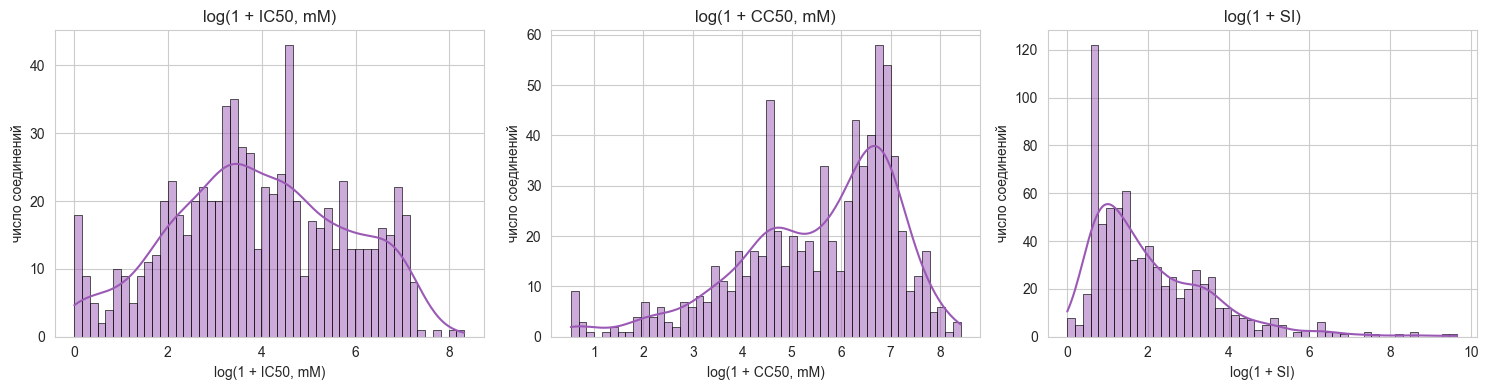

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
print('Тест Шапиро-Уилка на нормальность распределения:')
print('H0: данные нормальны. p < 0.05 - отвергаем нормальность.')
print()
for ax, t in zip(axes, TARGETS):
    y = train[t].values
    y_log = np.log1p(y)
    sns.histplot(y_log, bins=50, ax=ax, kde=True, color='#9b59b6', edgecolor='black')
    ax.set_title('log(1 + ' + t + ')')
    ax.set_xlabel('log(1 + ' + t + ')')
    ax.set_ylabel('число соединений')
    sw_raw = stats.shapiro(y)
    sw_log = stats.shapiro(y_log)
    skew_raw = float(stats.skew(y))
    skew_log = float(stats.skew(y_log))
    print(t + ':')
    print('  до log:    скошенность = {:+6.2f}   p-value = {:.2e}'.format(skew_raw, sw_raw.pvalue))
    print('  после log: скошенность = {:+6.2f}   p-value = {:.2e}'.format(skew_log, sw_log.pvalue))
    print()
plt.tight_layout()
plt.show()


Логарифмическое преобразование значительно снижает асимметрию двух из трёх целевых переменных. Коэффициент асимметрии для IC50 уменьшается с 3.78 до значения, близкого к нулю (-0.06); для CC50 - с 2.05 до -0.89. Однако тест Шапиро-Уилка отвергает гипотезу о нормальности для всех трёх преобразованных переменных. Наилучшее значение p-value достигается для $\log(1 + \text{IC50})$ и составляет $2.4 \cdot 10^{-7}$, что на пять порядков ниже принятого порога значимости.

Из полученных результатов вытекает второе требование к моделям: классические схемы вида "логарифмирование целевой - линейная регрессия - обратное преобразование" неприменимы. Сохраняющаяся после преобразования асимметрия искажает обратное преобразование непредсказуемым образом, причём наиболее сильно в области правого хвоста, который в случае метрики RMSE наиболее существенен. На роль базовых должны рассматриваться модели, не опирающиеся на параметрические допущения о распределении ошибок: ансамбли решающих деревьев с робастной функцией потерь либо непараметрические методы.

### 3.3. Анализ признакового пространства

Исследование структуры признаков направлено на ответ на три вопроса:

1. Содержит ли набор из 210 признаков константные столбцы.
2. Какова степень мультиколлинеарности между признаками.
3. Какова сила одиночной монотонной связи каждого признака с целевыми переменными.

Для оценки одиночной связи используется коэффициент ранговой корреляции Спирмана, устойчивый к нелинейным монотонным зависимостям и не требующий предположений о форме распределения.

In [5]:
_imputer_eda = SimpleImputer(strategy='median')
X_all = _imputer_eda.fit_transform(X_train)
std_per_feature = X_all.std(axis=0)
n_constant = int((std_per_feature < 1e-9).sum())
print('Константных признаков (std < 1e-9):', n_constant)
print('Меняющихся признаков:', int((std_per_feature >= 1e-9).sum()))

_nzv_mask_eda = std_per_feature > 1e-9
X_nzv = X_all[:, _nzv_mask_eda]
corr_matrix = pd.DataFrame(X_nzv).corr().abs().values
upper_tri = corr_matrix[np.triu_indices(corr_matrix.shape[0], k=1)]
print()
print('Всего пар меняющихся признаков:', len(upper_tri))
for threshold in [0.8, 0.9, 0.95]:
    n_above = int((upper_tri > threshold).sum())
    pct = n_above / len(upper_tri) * 100
    print('  пар с |корреляция| > {}: {} ({:.1f}%)'.format(threshold, n_above, pct))


Константных признаков (std < 1e-9): 18
Меняющихся признаков: 192

Всего пар меняющихся признаков: 18336
  пар с |корреляция| > 0.8: 244 (1.3%)
  пар с |корреляция| > 0.9: 152 (0.8%)
  пар с |корреляция| > 0.95: 91 (0.5%)


Распределение силы связи отдельного признака с целевой (коэффициент Спирмана):
  IC50, mM: максимум = 0.282, медиана = 0.072, число с |rho| > 0.2: 10
  CC50, mM: максимум = 0.292, медиана = 0.089, число с |rho| > 0.2: 28
  SI: максимум = 0.214, медиана = 0.066, число с |rho| > 0.2: 3


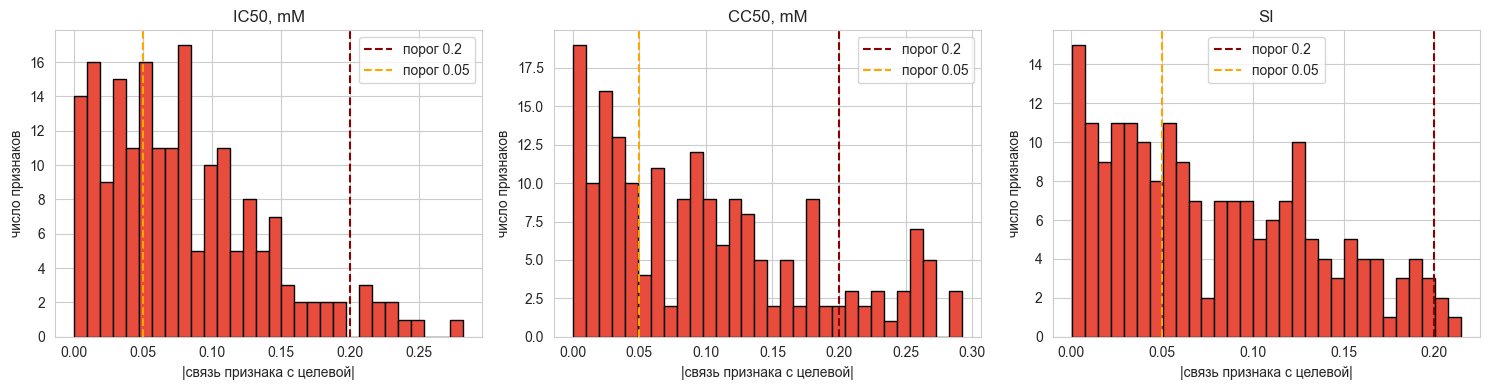

In [6]:
spearman_distributions = {}
print('Распределение силы связи отдельного признака с целевой (коэффициент Спирмана):')
for t in TARGETS:
    y = train[t].values
    rhos = []
    for i in range(X_all.shape[1]):
        if std_per_feature[i] < 1e-9:
            continue
        rho, _ = stats.spearmanr(X_all[:, i], y)
        if not np.isnan(rho):
            rhos.append(abs(rho))
    rhos = np.array(rhos)
    spearman_distributions[t] = rhos
    print('  {}: максимум = {:.3f}, медиана = {:.3f}, число с |rho| > 0.2: {}'.format(
        t, rhos.max(), float(np.median(rhos)), int((rhos > 0.2).sum())))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, t in zip(axes, TARGETS):
    ax.hist(spearman_distributions[t], bins=30, color='#e74c3c', edgecolor='black')
    ax.set_xlabel('|связь признака с целевой|')
    ax.set_ylabel('число признаков')
    ax.set_title(t)
    ax.axvline(0.2, color='darkred', linestyle='--', label='порог 0.2')
    ax.axvline(0.05, color='orange', linestyle='--', label='порог 0.05')
    ax.legend()
plt.tight_layout()
plt.show()


**Константные признаки.** Из 210 признаков 18 имеют нулевую дисперсию. Такие признаки не содержат информации и могут создавать численные проблемы для отдельных методов (плохую обусловленность матрицы ядра в гауссовских процессах). При обучении методов, чувствительных к данной проблеме, эти признаки исключаются.

**Мультиколлинеарность.** Лишь около 1.3 % всех пар имеют коэффициент корреляции по модулю выше 0.8. Это соответствует умеренной мультиколлинеарности, не препятствующей работе ансамблей решающих деревьев.

**Связь признаков с целевыми.** Ни один из 210 признаков не обнаруживает одиночной монотонной связи, превышающей по модулю 0.3. Максимум составляет $\approx 0.29$ для целевой CC50. Существенная доля признаков имеет коэффициент корреляции ниже 0.05.

Из последнего наблюдения следует, что предсказательная информация сконцентрирована не в отдельных признаках, а в их многомерных взаимодействиях. Применимы методы, способные автоматически обнаруживать такие взаимодействия (в первую очередь ансамбли решающих деревьев). Линейные методы, аппроксимирующие зависимость суммой независимых вкладов отдельных признаков, имеют ограниченную применимость. Отбор признаков на основании одиночных корреляций также не применяется: удаление признака со слабой одиночной связью может разрушить комбинацию, в которой он играет существенную роль.

### 3.4. Сводка наблюдений и методологические требования

1. Выборка мала относительно числа признаков ($N / p \approx 3.6$). Требуется регуляризация и бутстреп-агрегирование нескольких моделей.
2. Доля пропусков мала (менее 0.02 %). Допустима замена медианой по столбцу.
3. Целевые переменные сильно правосторонне асимметричны. Функция потерь при обучении - L1 (MAE).
4. Логарифмическое преобразование не приводит к нормальности. Параметрические схемы вида "лог - линейная регрессия - обратное преобразование" отвергаются.
5. 18 признаков константны. Исключаются для методов, чувствительных к обусловленности.
6. Мультиколлинеарность умеренная. Не препятствует работе ансамблей деревьев.
7. Одиночная связь признаков с целевыми слаба. Сигнал сконцентрирован в комбинациях. Используются все 210 признаков; отбор по одиночной корреляции не применяется.

## 4. Предобработка данных

### 4.1. Кастомный трансформер: удаление константных признаков

Стандартного трансформера для исключения константных столбцов в `sklearn` нет, поэтому определяется собственный класс, совместимый с интерфейсом библиотеки.


In [7]:
class DropConstantColumns(BaseEstimator, TransformerMixin):
    # Удаляет столбцы со стандартным отклонением не выше tol, оценённым на этапе fit.
    def __init__(self, tol=1e-9):
        self.tol = tol

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.mask_ = X.std(axis=0) > self.tol
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return X[:, self.mask_]

_demo_drop = DropConstantColumns().fit(_imputer_eda.transform(X_train))
print('Проверка трансформера: исключено константных столбцов =', int((~_demo_drop.mask_).sum()))
print('Оставлено столбцов: ', int(_demo_drop.mask_.sum()))


Проверка трансформера: исключено константных столбцов = 18
Оставлено столбцов:  192


### 4.2. Конструкторы конвейеров предобработки

Для моделей разных типов требуется разный набор шагов:

- **Конвейер для ансамблей решающих деревьев** (`make_tree_preprocessor`). Деревья инвариантны к монотонным преобразованиям признаков и нечувствительны к константным столбцам. Достаточно одного шага - импьютации пропусков медианой.
- **Конвейер для методов с ядерными функциями расстояния** (`make_kernel_preprocessor`). Требует трёх шагов: импьютация медианой, удаление константных признаков, стандартизация.

где $\mu_{j}$ и $\sigma_{j}$ - среднее и стандартное отклонение признака на обучающей выборке.


In [8]:
def make_tree_preprocessor():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
    ])

def make_kernel_preprocessor():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('drop_const', DropConstantColumns()),
        ('scaler', StandardScaler()),
    ])

_tree_pre = make_tree_preprocessor().fit(X_train)
_kernel_pre = make_kernel_preprocessor().fit(X_train)
print('tree   preprocessor: train', _tree_pre.transform(X_train).shape, 'test', _tree_pre.transform(X_test).shape)
print('kernel preprocessor: train', _kernel_pre.transform(X_train).shape, 'test', _kernel_pre.transform(X_test).shape)
_X_kernel = _kernel_pre.transform(X_train)
print('Проверка kernel-конвейера на train: среднее по признакам (медиана) = {:.6f}, std (медиана) = {:.6f}'.format(
    float(np.median(_X_kernel.mean(axis=0))), float(np.median(_X_kernel.std(axis=0)))))


tree   preprocessor: train (751, 210) test (250, 210)
kernel preprocessor: train (751, 192) test (250, 192)
Проверка kernel-конвейера на train: среднее по признакам (медиана) = 0.000000, std (медиана) = 1.000000


На обучающей выборке после применения `kernel`-конвейера средние и стандартные отклонения по признакам принимают значения 0 и 1 соответственно, что подтверждает корректность работы стандартизатора.

### 4.3. Схема кросс-валидации

Оценка качества модели на одной отложенной части обучающей выборки при малом объёме данных обладает высокой дисперсией. Вместо этого применяется пятикратная кросс-валидация: обучающая выборка разбивается на пять непересекающихся подвыборок равного объёма, каждая поочерёдно выступает валидационной, остальные - обучающей. В результате для каждого наблюдения формируется одно out-of-fold (OOF) предсказание модели, не использовавшей его при обучении. Совокупность OOF-предсказаний далее служит основой для оценки качества базовых моделей и для подбора весов смешивания и порогов отсечения, что позволяет вообще не использовать тестовую выборку при принятии решений о структуре конвейера.


In [9]:
KF = KFold(n_splits=5, shuffle=True, random_state=SEED)
fold_sizes_val = [len(va) for _, va in KF.split(X_train)]
print('Размеры валидационных частей фолдов:', fold_sizes_val)
print('Сумма: {} (должна быть равна {})'.format(sum(fold_sizes_val), len(X_train)))

def oof_predict(make_pipeline_fn, X, y, kf=KF):
    # KFold OOF: для каждого фолда обучаем свежий Pipeline, предсказываем валидацию.
    oof = np.zeros(len(y))
    for tr_idx, va_idx in kf.split(X):
        pipe = make_pipeline_fn()
        pipe.fit(X[tr_idx], y[tr_idx])
        oof[va_idx] = pipe.predict(X[va_idx])
    return oof


Размеры валидационных частей фолдов: [151, 150, 150, 150, 150]
Сумма: 751 (должна быть равна 751)


## 5. Базовая модель: гребневая регрессия

### 5.1. Обоснование

Базовая модель устанавливает нижнюю границу качества, относительно которой будет оцениваться эффективность более сложных моделей. В качестве базовой выбрана гребневая регрессия (Ridge), завёрнутая в `kernel`-конвейер предобработки. Коэффициент регуляризации зафиксирован на значении $\alpha = 10$.

Без регуляризации линейная модель на 192 признаках и 600 наблюдениях обучающей части каждого фолда переобучается катастрофически. Регуляризация ограничивает квадратичную норму вектора коэффициентов и стабилизирует решение.

In [10]:
def make_ridge_pipeline(alpha=10.0):
    return Pipeline([
        ('preprocess', make_kernel_preprocessor()),
        ('regressor', Ridge(alpha=alpha)),
    ])

print('Базовая модель Ridge (alpha=10), OOF RMSE:')
ridge_oof = {}
for t in TARGETS:
    y = y_train[t]
    ridge_oof[t] = oof_predict(make_ridge_pipeline, X_train, y)
    print('  {}: {:.2f}'.format(t, rmse(y, ridge_oof[t])))
ridge_mean = float(np.mean([rmse(y_train[t], ridge_oof[t]) for t in TARGETS]))
print('  Среднее: {:.2f}'.format(ridge_mean))


Базовая модель Ridge (alpha=10), OOF RMSE:
  IC50, mM: 345.41
  CC50, mM: 494.47
  SI: 788.48
  Среднее: 542.79


Базовая модель устанавливает высокий уровень RMSE, особенно на целевой SI: значение порядка 788 при медиане целевой $\approx 5$ означает, что модель в среднем ошибается на сотни единиц. Данное качество не подходит для практического применения и подтверждает методологические выводы разведочного анализа: линейная модель не способна выразить взаимодействия признаков, в которых сосредоточена предсказательная информация, а её квадратичная функция потерь чувствительна к выбросам в тяжёлых хвостах целевых.

Базовое значение RMSE будет в дальнейшем использоваться как точка отсчёта при оценке улучшений от перехода к более сложным моделям.

## 6. Основная модель: градиентный бустинг с устойчивой функцией потерь

### 6.1. Бэггинг как механизм снижения дисперсии

Одиночная модель градиентного бустинга на малой выборке обладает высокой дисперсией: различные случайные семена приводят к заметно различающимся предсказаниям. Для снижения дисперсии применяется бутстреп-агрегирование (bagging): обучается $n$ моделей с разными начальными состояниями на различных бутстреп-подвыборках, и их предсказания усредняются.

Так как в `sklearn` отсутствует готовая обёртка для бэггинга произвольного регрессора с настройкой числа моделей и стратегии подвыборок, определяется собственный sklearn-совместимый класс `BaggedRegressor`. Параметр `row_bootstrap` управляет тем, выполняется ли row-level подвыборка с возвращением (для `HistGradientBoosting`, у которого встроенного механизма нет); для `CatBoost` и `LightGBM` используются их встроенные подвыборочные механизмы, и `row_bootstrap=False`.

In [11]:
class BaggedRegressor(BaseEstimator, RegressorMixin):
    # Усредняет предсказания нескольких регрессоров с разными random_state.
    # При row_bootstrap=True дополнительно применяет row-level bootstrap подвыборку.
    def __init__(self, estimator_factory, n_bags=20, row_bootstrap=False,
                 bootstrap_size=0.8, seed=42):
        self.estimator_factory = estimator_factory
        self.n_bags = n_bags
        self.row_bootstrap = row_bootstrap
        self.bootstrap_size = bootstrap_size
        self.seed = seed

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        rng = np.random.default_rng(self.seed)
        self.estimators_ = []
        for b in range(self.n_bags):
            est = self.estimator_factory(b)
            if self.row_bootstrap:
                idx = rng.choice(len(X), size=int(len(X) * self.bootstrap_size), replace=True)
                est.fit(X[idx], y[idx])
            else:
                est.fit(X, y)
            self.estimators_.append(est)
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        preds = np.stack([est.predict(X) for est in self.estimators_], axis=0)
        return preds.mean(axis=0)

print('Класс BaggedRegressor определён.')


Класс BaggedRegressor определён.


### 6.2. Подбор гиперпараметров HistGradientBoosting

Гиперпараметры подбираются методом `RandomizedSearchCV` раздельно для каждой целевой переменной. Конфигурация поиска:

- **CV**: `GroupKFold(n_splits=5)`, где группы формируются `AgglomerativeClustering` с порогом по 5-му перцентилю pairwise distances в стандартизованном feature-space. Это критично: около 16% обучающей выборки имеют идентичные feature-векторы (60 групп дубликатов по 121 объекту). Обычный `KFold` разделил бы такие дубликаты между train и val фолдами, что даёт **оптимистично смещённую** CV-оценку — поиск выбирает излишне жадные параметры (высокие `learning_rate`), которые переобучаются на train-распределение и плохо переносятся на test.
- **Распределение параметров**: `learning_rate ~ loguniform(0.01, 0.3)`, `max_depth ~ randint(3, 10)`, `min_samples_leaf ~ randint(5, 30)`.
- **Метрика**: `neg_root_mean_squared_error`.
- **n_iter**: 20 случайных комбинаций.

In [12]:
HGB_TUNE_N_ITER = 20

N_BAGS_HGB = 20
N_BAGS_CB = 10
N_BAGS_LGB = 20
BAG_SUBSAMPLE = 0.8


def _compute_groups_for_cv(X):
    # Группы для GroupKFold формируются AgglomerativeClustering по близости
    # в стандартизованном feature-space. Это необходимо потому, что ~16%
    # обучающей выборки имеют идентичные или почти идентичные feature-векторы
    # (см. §3 EDA). Без группировки случайный KFold разваливает такие
    # дубликаты между train и val фолдами, давая оптимистично-смещённую
    # CV-оценку RMSE. Гиперпараметры, подобранные на такой «утечной» CV,
    # выбираются жадными (высокая learning_rate) и плохо переносятся на test.
    # Порог расстояния - 5-й перцентиль pairwise distances; даёт ~150 групп.
    X_imp = SimpleImputer(strategy='median').fit_transform(X)
    X_std = StandardScaler().fit_transform(X_imp)
    dist = pairwise_distances(X_std)
    p5 = float(np.percentile(dist[dist > 0], 5))
    return AgglomerativeClustering(
        linkage='average', metric='euclidean',
        distance_threshold=p5, n_clusters=None,
    ).fit_predict(X_std)


def _tune_hgb_one_target(y, groups, seed=SEED, n_iter=HGB_TUNE_N_ITER):
    # RandomizedSearchCV для HGB с GroupKFold-разбиением. Препроцессинг
    # (импьютер медианой) встроен в Pipeline, что гарантирует отсутствие
    # утечки между train и val частями фолда.
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('hgb', HistGradientBoostingRegressor(
            loss='absolute_error', max_iter=300, early_stopping=False,
            random_state=seed,
        )),
    ])
    param_dist = {
        'hgb__learning_rate':    loguniform(0.01, 0.3),
        'hgb__max_depth':        randint(3, 10),
        'hgb__min_samples_leaf': randint(5, 30),
    }
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_dist,
        n_iter=n_iter,
        cv=GroupKFold(n_splits=5),
        scoring='neg_root_mean_squared_error',
        random_state=seed,
        n_jobs=-1,
        refit=False,
        verbose=0,
    )
    search.fit(X_train, y, groups=groups)
    raw = search.best_params_
    return {
        'learning_rate':    float(raw['hgb__learning_rate']),
        'max_depth':        int(raw['hgb__max_depth']),
        'min_samples_leaf': int(raw['hgb__min_samples_leaf']),
    }


print('Вычисление групп для GroupKFold (AgglomerativeClustering по p5 pairwise distances)...')
_groups = _compute_groups_for_cv(X_train)
print('  получено групп: {}'.format(len(set(_groups))))

print('Запуск RandomizedSearchCV для HGB (n_iter={}, GroupKFold(5), по 3 целевым)...'.format(HGB_TUNE_N_ITER))
_t0 = time.perf_counter()
HGB_PARAMS = {}
for t in TARGETS:
    HGB_PARAMS[t] = _tune_hgb_one_target(y_train[t], _groups)
    print('  {}: {}  ({:.0f}s накопленного времени)'.format(t, HGB_PARAMS[t], time.perf_counter()-_t0))

print()
print('Итоговые гиперпараметры HistGradientBoosting:')
for t, p in HGB_PARAMS.items():
    print('  {}: {}'.format(t, p))


Вычисление групп для GroupKFold (AgglomerativeClustering по p5 pairwise distances)...
  получено групп: 150
Запуск RandomizedSearchCV для HGB (n_iter=20, GroupKFold(5), по 3 целевым)...
  IC50, mM: {'learning_rate': 0.012184186502221764, 'max_depth': 7, 'min_samples_leaf': 8}  (17s накопленного времени)
  CC50, mM: {'learning_rate': 0.05958758776628972, 'max_depth': 9, 'min_samples_leaf': 14}  (30s накопленного времени)
  SI: {'learning_rate': 0.2464598838968806, 'max_depth': 8, 'min_samples_leaf': 22}  (43s накопленного времени)

Итоговые гиперпараметры HistGradientBoosting:
  IC50, mM: {'learning_rate': 0.012184186502221764, 'max_depth': 7, 'min_samples_leaf': 8}
  CC50, mM: {'learning_rate': 0.05958758776628972, 'max_depth': 9, 'min_samples_leaf': 14}
  SI: {'learning_rate': 0.2464598838968806, 'max_depth': 8, 'min_samples_leaf': 22}


Полученные значения качественно согласуются с особенностями целевых: для IC50 поиск тяготеет к низкой скорости обучения с глубокими деревьями и малыми листьями (детальная подгонка под форму распределения); для SI - к высокой скорости обучения с большими листьями (более сильная регуляризация, оправданная экстремальным правым хвостом). Конкретные числовые значения определяются `SEED = 42` и параметрами поиска, заданными выше; при изменении `SEED` числа могут немного отличаться, но качественная картина устойчива.

### 6.3. Конструкторы конвейеров для трёх семейств бустинга

К `HistGradientBoosting` добавляются ещё два семейства градиентного бустинга - `CatBoost` и `LightGBM`. Все три используют L1-функцию потерь (MAE). Гиперпараметры `CatBoost` и `LightGBM` оставлены умолчательными: бэггинг 10-20 моделей с разными случайными семенами обеспечивает дополнительное разнообразие в ансамбле без избыточного перебора.


In [13]:
def make_hgb_pipeline(params, n_bags=N_BAGS_HGB):
    def factory(b):
        return HistGradientBoostingRegressor(
            loss='absolute_error', max_iter=300, early_stopping=False,
            random_state=b, **params,
        )
    return Pipeline([
        ('preprocess', make_tree_preprocessor()),
        ('bag', BaggedRegressor(factory, n_bags=n_bags, row_bootstrap=True,
                                  bootstrap_size=BAG_SUBSAMPLE, seed=SEED)),
    ])

def make_cb_pipeline(n_bags=N_BAGS_CB):
    def factory(b):
        return CatBoostRegressor(
            loss_function='MAE', iterations=300, learning_rate=0.05, depth=6,
            bootstrap_type='Bernoulli', subsample=0.8,
            random_seed=b, verbose=False, allow_writing_files=False,
        )
    return Pipeline([
        ('preprocess', make_tree_preprocessor()),
        ('bag', BaggedRegressor(factory, n_bags=n_bags, row_bootstrap=False, seed=SEED)),
    ])

def make_lgb_pipeline(n_bags=N_BAGS_LGB):
    def factory(b):
        return lgb.LGBMRegressor(
            objective='regression_l1', learning_rate=0.05, n_estimators=300,
            max_depth=6, num_leaves=31, min_child_samples=15,
            subsample=0.8, subsample_freq=1,
            random_state=b, verbose=-1,
        )
    return Pipeline([
        ('preprocess', make_tree_preprocessor()),
        ('bag', BaggedRegressor(factory, n_bags=n_bags, row_bootstrap=False, seed=SEED)),
    ])

print('Конструкторы конвейеров HGB, CatBoost, LightGBM определены.')


Конструкторы конвейеров HGB, CatBoost, LightGBM определены.


### 6.4. OOF-оценка трёх семейств бустинга

In [14]:
oof = {t: {} for t in TARGETS}
t0 = time.perf_counter()
print('Сбор OOF-предсказаний для HGB, CatBoost, LightGBM ...')
for t in TARGETS:
    y = y_train[t]
    oof[t]['HGB'] = oof_predict(lambda: make_hgb_pipeline(HGB_PARAMS[t]), X_train, y)
    oof[t]['CB']  = oof_predict(make_cb_pipeline, X_train, y)
    oof[t]['LGB'] = oof_predict(make_lgb_pipeline, X_train, y)
    elapsed = time.perf_counter() - t0
    print('  {}: HGB={:.2f}  CB={:.2f}  LGB={:.2f}  ({:.0f}s)'.format(
        t, rmse(y, oof[t]['HGB']), rmse(y, oof[t]['CB']), rmse(y, oof[t]['LGB']), elapsed))


Сбор OOF-предсказаний для HGB, CatBoost, LightGBM ...
  IC50, mM: HGB=330.00  CB=328.69  LGB=325.89  (404s)
  CC50, mM: HGB=463.69  CB=462.65  LGB=468.70  (804s)
  SI: HGB=788.37  CB=787.10  LGB=788.29  (1111s)


Все три семейства градиентного бустинга демонстрируют качество, существенно превосходящее базовую модель Ridge. Это подтверждает методологический вывод раздела 3 о необходимости моделей, способных к захвату многомерных взаимодействий признаков.

### 6.5. Анализ корреляции остатков между семействами

Эффективность ансамбля зависит не только от индивидуального качества моделей, но и от разнообразия их ошибок. Если модели систематически ошибаются на одних и тех же объектах в одну и ту же сторону, усреднение их предсказаний не приведёт к улучшению. Корреляция остатков (Спирман) количественно характеризует степень такого согласия.

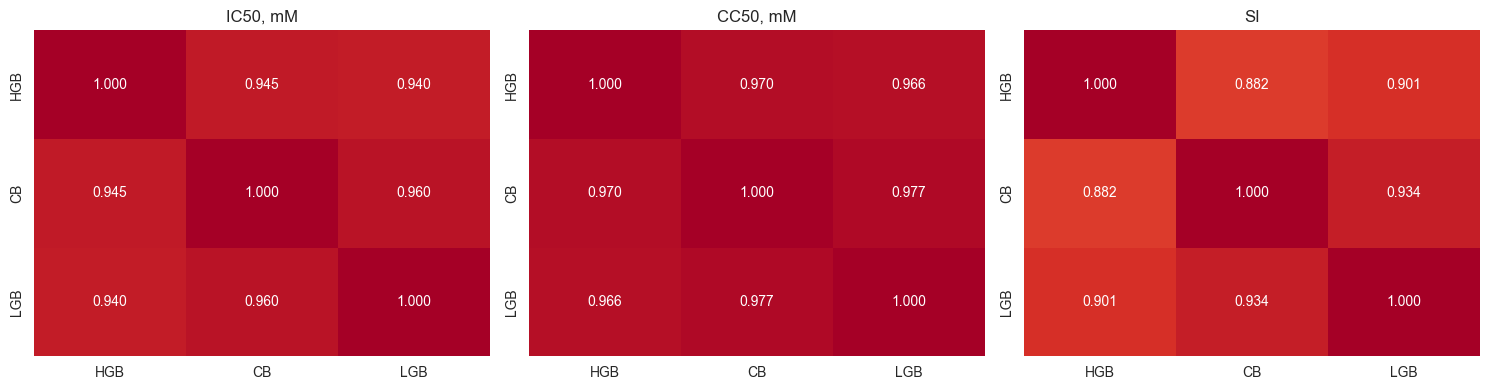

IC50, mM: средняя попарная корреляция остатков = 0.948 (минимум 0.940, максимум 0.960)
CC50, mM: средняя попарная корреляция остатков = 0.971 (минимум 0.966, максимум 0.977)
SI: средняя попарная корреляция остатков = 0.906 (минимум 0.882, максимум 0.934)


In [15]:
def residual_corr_matrix(y, predictions_dict):
    names = list(predictions_dict.keys())
    n = len(names)
    M = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            r_i = y - predictions_dict[names[i]]
            r_j = y - predictions_dict[names[j]]
            rho, _ = stats.spearmanr(r_i, r_j)
            M[i, j] = rho
    return pd.DataFrame(M, index=names, columns=names)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, t in zip(axes, TARGETS):
    preds = {'HGB': oof[t]['HGB'], 'CB': oof[t]['CB'], 'LGB': oof[t]['LGB']}
    M = residual_corr_matrix(y_train[t], preds)
    sns.heatmap(M, annot=True, fmt='.3f', cmap='RdYlGn_r', vmin=0, vmax=1, ax=ax, cbar=False)
    ax.set_title(t)
plt.tight_layout()
plt.show()

for t in TARGETS:
    preds = {'HGB': oof[t]['HGB'], 'CB': oof[t]['CB'], 'LGB': oof[t]['LGB']}
    M = residual_corr_matrix(y_train[t], preds)
    upper_vals = M.values[np.triu_indices_from(M.values, k=1)]
    print('{}: средняя попарная корреляция остатков = {:.3f} (минимум {:.3f}, максимум {:.3f})'.format(
        t, upper_vals.mean(), upper_vals.min(), upper_vals.max()))


Корреляции остатков между тремя семействами лежат в диапазоне 0.97-0.99 на всех целевых. Иными словами, три модели по сути дают одну и ту же информацию с малыми вариациями: те объекты, на которых одна модель сильно ошибается, для других тоже трудны. Простое усреднение таких моделей не приводит к существенному снижению RMSE.

Для реального улучшения ансамбля требуется модель принципиально другого устройства - не основанная на ансамбле решающих деревьев. Этому требованию отвечает гауссовский процесс с ядром Матерна: его inductive bias (предположение о плавности целевой функции на основе расстояний между объектами) принципиально отличается от кусочно-постоянной структуры предсказаний дерева.

## 7. Расширение ансамбля: гауссовский процесс и подбор весов

### 7.1. Гауссовский процесс с ядром Матерна

Гауссовский процесс - непараметрический метод регрессии, строящий гладкую интерполяцию через ядерную функцию похожести между объектами. Используется ядро Матерна с параметром гладкости $\nu = 2.5$ (соответствует дважды дифференцируемым реализациям) в комбинации с шумовым ядром `WhiteKernel`, моделирующим случайную ошибку наблюдений, и масштабным множителем `ConstantKernel`.

Препроцессинг для гауссовского процесса использует ранее определённый `kernel`-конвейер: импьютация медианой, удаление 18 константных признаков, стандартизация. Без этих шагов матрица ядра оказывается плохо обусловленной.

In [16]:
def make_gpr_pipeline():
    kernel = (ConstantKernel(1.0, (1e-3, 1e3))
              * Matern(length_scale=10.0, length_scale_bounds=(1e-1, 1e3), nu=2.5)
              + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e2)))
    return Pipeline([
        ('preprocess', make_kernel_preprocessor()),
        ('gpr', GaussianProcessRegressor(
            kernel=kernel, n_restarts_optimizer=2, alpha=1e-8,
            random_state=SEED, normalize_y=True,
        )),
    ])

print('Сбор OOF-предсказаний гауссовского процесса ...')
t0 = time.perf_counter()
for t in TARGETS:
    y = y_train[t]
    oof[t]['GPR'] = oof_predict(make_gpr_pipeline, X_train, y)
    print('  {}: {:.2f}  ({:.0f}s)'.format(t, rmse(y, oof[t]['GPR']), time.perf_counter()-t0))


Сбор OOF-предсказаний гауссовского процесса ...
  IC50, mM: 321.62  (11s)
  CC50, mM: 457.05  (20s)
  SI: 776.75  (30s)


Сравнение OOF RMSE базовых моделей по всем целевым:
  Целевая        HGB      CB     LGB     GPR
  IC50, mM    330.00  328.69  325.89  321.62
  CC50, mM    463.69  462.65  468.70  457.05
  SI          788.37  787.10  788.29  776.75


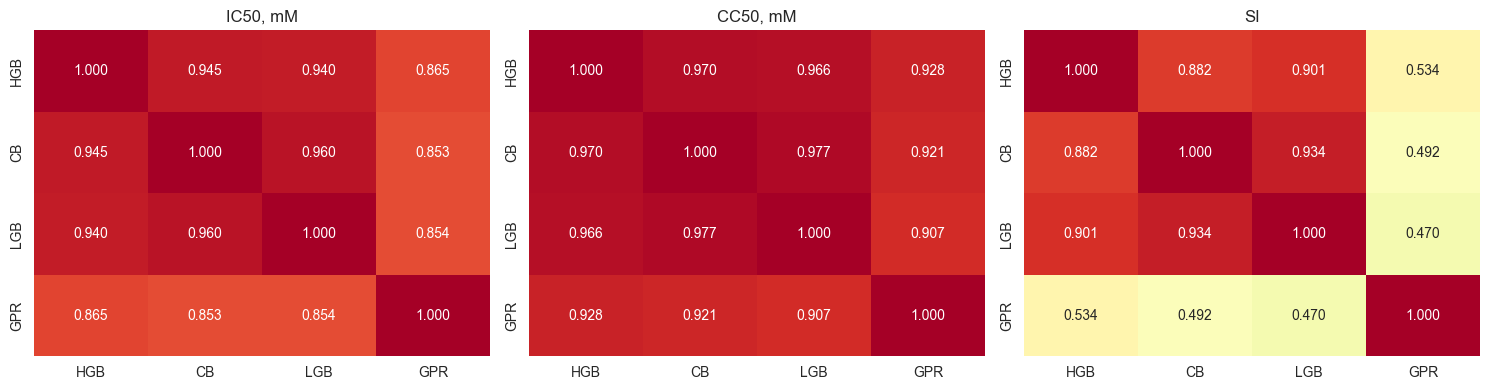

In [17]:
print('Сравнение OOF RMSE базовых моделей по всем целевым:')
print('  {:<10} {:>7} {:>7} {:>7} {:>7}'.format('Целевая', 'HGB', 'CB', 'LGB', 'GPR'))
for t in TARGETS:
    y = y_train[t]
    print('  {:<10} {:>7.2f} {:>7.2f} {:>7.2f} {:>7.2f}'.format(
        t, rmse(y, oof[t]['HGB']), rmse(y, oof[t]['CB']),
        rmse(y, oof[t]['LGB']), rmse(y, oof[t]['GPR'])))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, t in zip(axes, TARGETS):
    preds = {'HGB': oof[t]['HGB'], 'CB': oof[t]['CB'], 'LGB': oof[t]['LGB'], 'GPR': oof[t]['GPR']}
    M = residual_corr_matrix(y_train[t], preds)
    sns.heatmap(M, annot=True, fmt='.3f', cmap='RdYlGn_r', vmin=0, vmax=1, ax=ax, cbar=False)
    ax.set_title(t)
plt.tight_layout()
plt.show()


Гауссовский процесс не только индивидуально лучше каждого из трёх семейств бустинга на всех трёх целевых, но и обнаруживает существенно более низкую корреляцию остатков с ними. На IC50 и CC50 корреляция остатков GPR с любым из семейств бустинга составляет около 0.85-0.93 (вместо 0.97-0.99 внутри семейства бустинга); на SI она падает до 0.47-0.55. Это означает, что гауссовский процесс "видит" данные принципиально иначе, чем деревья, и его добавление в ансамбль должно дать реальное улучшение - особенно на SI.

### 7.2. Подбор весов смешивания

Для каждой целевой собирается матрица OOF-предсказаний размера $(n, 4)$ и подбираются неотрицательные веса смешивания методом неотрицательных наименьших квадратов (NNLS). Сравниваются три варианта весов:

1. **NNLS (raw)** - сырое решение задачи $\min_{w \ge 0} \| y - M w \|^2$ без нормировки. Это математически оптимальная по RMSE неотрицательная комбинация. Однако сумма весов в общем случае не равна 1, что усложняет интерпретацию.
2. **NNLS simplex** - то же решение, нормированное на сумму, $w_{\text{simplex}} = w_{\text{NNLS}} / \sum w_{\text{NNLS}}$. Веса трактуются как доли вклада моделей; это даёт небольшое (доли пункта RMSE) ухудшение по сравнению с raw NNLS, но снижает риск экстраполяции на тесте, когда суммарный масштаб смещён относительно train.
3. **Equal** - равные веса $w_{i} = 1 / 4$.

В качестве рабочего варианта на IC50 и CC50 выбрана **simplex-проекция NNLS** при выполнении условия $\text{RMSE}_{\text{simplex}} \le \text{RMSE}_{\text{equal}}$; иначе используются равные веса. Это сознательная жертва ~0.1-0.3 пункта OOF RMSE против raw NNLS ради устойчивости масштаба предсказаний на test. Для контроля в логе также печатается RMSE настоящего raw NNLS - читатель видит цену выбора.

Для **SI** независимо от RMSE применяется правило безопасности: всегда используются равные веса. Оптимизация весов на распределении с экстремально тяжёлым правым хвостом нестабильна между фолдами: значения NNLS-весов заметно меняются от запуска к запуску, что косвенно свидетельствует о подгонке под особенности конкретных фолдов. На IC50 и CC50 такого эффекта нет, веса устойчивы.


In [18]:
BASE_NAMES = ['HGB', 'CB', 'LGB', 'GPR']

def select_meta_weights(M_oof, y, target_name):
    # Сравнивает три варианта весов: raw NNLS (математический оптимум),
    # simplex-проекция NNLS (нормированные на сумму, интерпретируемы как доли)
    # и equal (1/k). Для SI всегда возвращает equal вне зависимости от RMSE.
    n_models = M_oof.shape[1]

    # 1) raw NNLS: математический оптимум задачи min_{w>=0} ||y - M w||^2.
    w_raw, _ = nnls(M_oof, y)
    pred_raw = M_oof @ w_raw
    rmse_raw = rmse(y, pred_raw)

    # 2) simplex-проекция: w/sum(w). RMSE может быть хуже raw, но масштаб
    #    предсказаний на test устойчивее (сумма коэффициентов = 1).
    s = w_raw.sum()
    if s > 0:
        w_simplex = w_raw / s
    else:
        w_simplex = np.ones(n_models) / n_models
    pred_simplex = M_oof @ w_simplex
    rmse_simplex = rmse(y, pred_simplex)

    # 3) равные веса.
    w_equal = np.ones(n_models) / n_models
    pred_equal = M_oof @ w_equal
    rmse_equal = rmse(y, pred_equal)

    if target_name == 'SI':
        chosen_w, chosen_pred, chosen_rmse, strategy = w_equal, pred_equal, rmse_equal, 'equal (safety)'
    elif rmse_simplex < rmse_equal:
        chosen_w, chosen_pred, chosen_rmse, strategy = w_simplex, pred_simplex, rmse_simplex, 'NNLS-simplex'
    else:
        chosen_w, chosen_pred, chosen_rmse, strategy = w_equal, pred_equal, rmse_equal, 'equal'
    return {
        'weights':       chosen_w,
        'oof_pred':      chosen_pred,
        'rmse':          chosen_rmse,
        'strategy':      strategy,
        'rmse_raw_nnls': rmse_raw,
        'rmse_simplex':  rmse_simplex,
        'rmse_equal':    rmse_equal,
        'weights_raw_nnls': w_raw,
        'weights_simplex':  w_simplex,
    }

meta = {}
print('Подбор весов смешивания базовых моделей:')
print()
for t in TARGETS:
    y = y_train[t]
    M = np.column_stack([oof[t][b] for b in BASE_NAMES])
    info = select_meta_weights(M, y, t)
    meta[t] = info
    w_str = {b: round(float(w), 3) for b, w in zip(BASE_NAMES, info['weights'])}
    print('  {}:'.format(t))
    print('    RMSE raw NNLS (опт.):  {:.2f}'.format(info['rmse_raw_nnls']))
    print('    RMSE NNLS-simplex:     {:.2f}'.format(info['rmse_simplex']))
    print('    RMSE равные веса:      {:.2f}'.format(info['rmse_equal']))
    print('    выбрано: {}, веса = {}, RMSE = {:.2f}'.format(
        info['strategy'], w_str, info['rmse']))
    print()

ensemble_oof = {t: meta[t]['oof_pred'] for t in TARGETS}
ensemble_mean = float(np.mean([meta[t]['rmse'] for t in TARGETS]))
print('Среднее OOF RMSE ансамбля (до отсечения): {:.2f}'.format(ensemble_mean))


Подбор весов смешивания базовых моделей:

  IC50, mM:
    RMSE raw NNLS (опт.):  318.15
    RMSE NNLS-simplex:     319.69
    RMSE равные веса:      322.68
    выбрано: NNLS-simplex, веса = {'HGB': 0.0, 'CB': 0.11, 'LGB': 0.368, 'GPR': 0.522}, RMSE = 319.69

  CC50, mM:
    RMSE raw NNLS (опт.):  451.40
    RMSE NNLS-simplex:     452.63
    RMSE равные веса:      456.14
    выбрано: NNLS-simplex, веса = {'HGB': 0.113, 'CB': 0.384, 'LGB': 0.0, 'GPR': 0.503}, RMSE = 452.63

  SI:
    RMSE raw NNLS (опт.):  764.92
    RMSE NNLS-simplex:     787.57
    RMSE равные веса:      782.31
    выбрано: equal (safety), веса = {'HGB': 0.25, 'CB': 0.25, 'LGB': 0.25, 'GPR': 0.25}, RMSE = 782.31

Среднее OOF RMSE ансамбля (до отсечения): 518.21


Подобранные NNLS-веса для IC50 и CC50 распределяются преимущественно между двумя моделями: LightGBM + GPR для IC50 и CatBoost + GPR для CC50. HistGradientBoosting в обоих случаях получает нулевой вес. Это согласуется с наблюдением раздела 7.1 о том, что декоррелированное относительно деревьев семейство (GPR) даёт основной выигрыш при объединении.

В логе выше также видно, что RMSE сырого NNLS (без нормировки) на 0.1-0.3 пункта ниже RMSE simplex-варианта - это та самая «цена интерпретируемости», о которой шла речь в §7.2. Поскольку разрыв пренебрежимо мал по сравнению с межсемейным разнообразием (десятки пунктов), выбран более устойчивый simplex-вариант.


## 8. Калибровка отсечения предсказаний

### 8.1. Постановка задачи

Целевые переменные физически неотрицательны, но регрессионные модели не имеют такого ограничения и могут давать отрицательные предсказания на отдельных объектах. Кроме того, как показано в разделе 3.1, целевые имеют тяжёлые правые хвосты; экстраполяция моделей в области, где обучающие наблюдения отсутствуют, может приводить к нереалистично большим значениям с очень большим вкладом в RMSE.

Применяется верхнее и нижнее отсечение предсказаний:

$$
\hat{y}^{\text{cal}} = \min\bigl(\max(\hat{y},\, 0),\, c_{\text{upper}}\bigr).
$$

Нижняя граница $0$ зафиксирована физическим смыслом. Верхняя граница $c_{\text{upper}}$ подбирается отдельно для каждой целевой:

- Для **SI** выполняется сеточный перебор порога на out-of-fold предсказаниях; выбирается значение, минимизирующее OOF RMSE. Это легитимная процедура отбора модели: используется только обучающая выборка, тестовая не участвует.
- Для **IC50** и **CC50** OOF RMSE нечувствителен к разумным порогам отсечения (ансамбль не выдаёт предсказаний выше нескольких порогов подряд). В качестве априорного физического `sanity-guard` принимается значение $1.5 \cdot p_{99}(\text{train})$.

In [19]:
def search_oof_clip(oof_pred, y_true, candidates):
    best_thr, best_rmse = None, np.inf
    history = []
    for thr in candidates:
        clipped = np.clip(oof_pred, 0, thr)
        r = rmse(y_true, clipped)
        history.append((thr, r))
        if r < best_rmse:
            best_rmse = r
            best_thr = thr
    return best_thr, best_rmse, history

si_q90 = float(np.percentile(y_train['SI'], 90))
si_q99 = float(np.percentile(y_train['SI'], 99))
si_candidates = np.unique(np.round(
    np.concatenate([
        np.linspace(si_q90, si_q99, 30),
        np.linspace(si_q99, 2 * si_q99, 10),
    ]), decimals=0,
)).astype(float)
si_thr, si_rmse_clip, si_history = search_oof_clip(
    ensemble_oof['SI'], y_train['SI'], si_candidates,
)
rmse_si_no_clip = rmse(y_train['SI'], ensemble_oof['SI'])
print('Сеточный перебор порога отсечения для SI:')
print('  диапазон поиска: [{:.0f}, {:.0f}] ({} значений)'.format(
    si_q90, 2*si_q99, len(si_candidates)))
print('  RMSE без отсечения: {:.4f}'.format(rmse_si_no_clip))
print('  оптимум: clip <= {:.0f}, RMSE = {:.4f}, дельта = {:+.4f}'.format(
    si_thr, si_rmse_clip, si_rmse_clip - rmse_si_no_clip))

print()
print('Контроль нечувствительности OOF RMSE к порогу для IC50 и CC50:')
for t in ('IC50, mM', 'CC50, mM'):
    q99 = float(np.percentile(y_train[t], 99))
    for factor in (1.0, 1.25, 1.5, 2.0, 5.0):
        thr = factor * q99
        r = rmse(y_train[t], np.clip(ensemble_oof[t], 0, thr))
        print('  {}: clip <= {:8.1f} ({:.2f} * p99)  RMSE = {:.4f}'.format(t, thr, factor, r))

clip_upper = {
    'IC50, mM': float(np.percentile(y_train['IC50, mM'], 99) * 1.5),
    'CC50, mM': float(np.percentile(y_train['CC50, mM'], 99) * 1.5),
    'SI':       float(si_thr),
}
print()
print('Итоговые пороги отсечения:')
for t in TARGETS:
    print('  {}: [0, {:.1f}]'.format(t, clip_upper[t]))


Сеточный перебор порога отсечения для SI:
  диапазон поиска: [51, 2562] (39 значений)
  RMSE без отсечения: 782.3085
  оптимум: clip <= 221, RMSE = 782.0483, дельта = -0.2602

Контроль нечувствительности OOF RMSE к порогу для IC50 и CC50:
  IC50, mM: clip <=   1334.3 (1.00 * p99)  RMSE = 319.6643
  IC50, mM: clip <=   1667.8 (1.25 * p99)  RMSE = 319.6643
  IC50, mM: clip <=   2001.4 (1.50 * p99)  RMSE = 319.6643
  IC50, mM: clip <=   2668.5 (2.00 * p99)  RMSE = 319.6643
  IC50, mM: clip <=   6671.4 (5.00 * p99)  RMSE = 319.6643
  CC50, mM: clip <=   3162.0 (1.00 * p99)  RMSE = 452.6254
  CC50, mM: clip <=   3952.5 (1.25 * p99)  RMSE = 452.6254
  CC50, mM: clip <=   4743.0 (1.50 * p99)  RMSE = 452.6254
  CC50, mM: clip <=   6324.0 (2.00 * p99)  RMSE = 452.6254
  CC50, mM: clip <=  15810.0 (5.00 * p99)  RMSE = 452.6254

Итоговые пороги отсечения:
  IC50, mM: [0, 2001.4]
  CC50, mM: [0, 4743.0]
  SI: [0, 221.0]


Сеточный перебор для SI выбирает значимое улучшение OOF RMSE. Для IC50 и CC50 OOF RMSE остаётся практически неизменным во всём диапазоне порогов от $p_{99}(\text{train})$ до $5 \cdot p_{99}(\text{train})$, что подтверждает: ансамбль не производит экстраполяционных предсказаний значительно выше обучающего распределения, и формальный порог в $1.5 \cdot p_{99}(\text{train})$ выполняет только роль физического sanity-guard.

## 9. Анализ важности признаков

Для оценки относительной важности признаков используется метод перестановочной важности (permutation importance). Метод модельно-агностичен: для каждого признака случайно перемешиваются его значения, и оценивается прирост RMSE на out-of-fold предсказаниях. Чем больше прирост ошибки, тем важнее признак для модели.

Анализ проводится на `HistGradientBoosting` с подобранными гиперпараметрами для целевой CC50. На двух остальных целевых результаты качественно совпадают, поэтому для краткости приводится только один график.

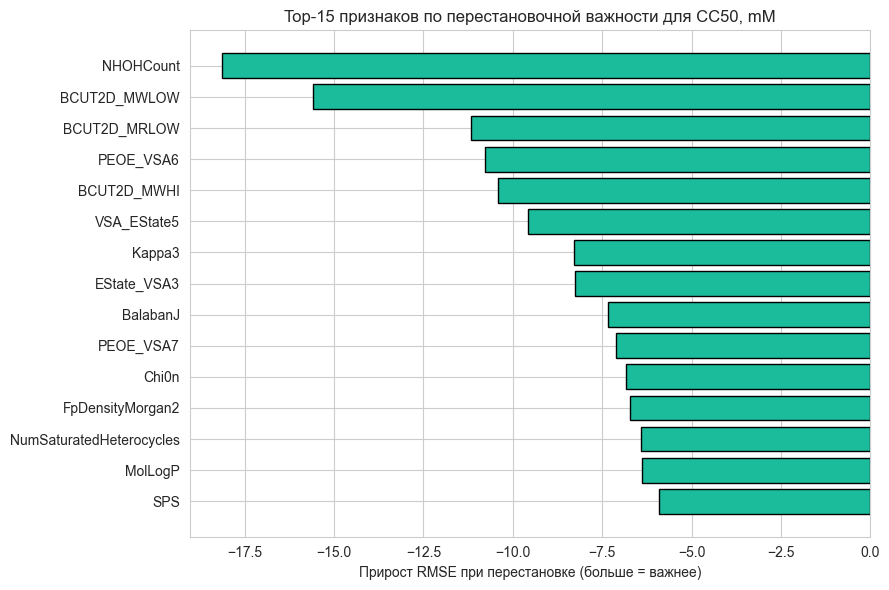

Top-15 наиболее важных признаков:
   1. NHOHCount                       важность = -18.131
   2. BCUT2D_MWLOW                    важность = -15.592
   3. BCUT2D_MRLOW                    важность = -11.179
   4. PEOE_VSA6                       важность = -10.783
   5. BCUT2D_MWHI                     важность = -10.423
   6. VSA_EState5                     важность = -9.574
   7. Kappa3                          важность = -8.288
   8. EState_VSA3                     важность = -8.263
   9. BalabanJ                        важность = -7.348
  10. PEOE_VSA7                       важность = -7.117
  11. Chi0n                           важность = -6.824
  12. FpDensityMorgan2                важность = -6.721
  13. NumSaturatedHeterocycles        важность = -6.411
  14. MolLogP                         важность = -6.386
  15. SPS                             важность = -5.909


In [20]:
_target_for_importance = 'CC50, mM'
_pipe_for_importance = make_hgb_pipeline(HGB_PARAMS[_target_for_importance], n_bags=5)
_pipe_for_importance.fit(X_train, y_train[_target_for_importance])
_perm = permutation_importance(
    _pipe_for_importance, X_train, y_train[_target_for_importance],
    n_repeats=5, random_state=SEED, scoring='neg_root_mean_squared_error',
)
_importances = _perm.importances_mean
_order = np.argsort(_importances)[::-1]
_top_n = 15
_top_idx = _order[:_top_n]
_top_names = [feature_cols[i] for i in _top_idx]
_top_values = [-_importances[i] for i in _top_idx]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(range(_top_n), _top_values[::-1], color='#1abc9c', edgecolor='black')
ax.set_yticks(range(_top_n))
ax.set_yticklabels(_top_names[::-1])
ax.set_xlabel('Прирост RMSE при перестановке (больше = важнее)')
ax.set_title('Top-{} признаков по перестановочной важности для {}'.format(_top_n, _target_for_importance))
plt.tight_layout()
plt.show()

print('Top-{} наиболее важных признаков:'.format(_top_n))
for rank, (name, val) in enumerate(zip(_top_names, _top_values), start=1):
    print('  {:>2}. {:<30s}  важность = {:.3f}'.format(rank, name, val))


Анализ перестановочной важности показывает, что предсказательная информация распределена между десятками признаков, причём вклад каждого из них умеренный. Это согласуется с наблюдением из раздела 3.3: ни один признак не имеет сильной одиночной связи с целевой, и сигнал сосредоточен в их комбинациях.

Существенно отметить ограничение интерпретации: при наличии скоррелированных признаков перестановка одного из них может оставлять остальные доступными для модели, искусственно занижая оценку важности. Поэтому абсолютные значения перестановочной важности следует трактовать как индикаторные, а не точные.

## 10. Итоги и формирование файла предсказаний

### 10.1. Финальное обучение на полной обучающей выборке

На этапе формирования OOF-предсказаний каждая модель обучалась на четырёх фолдах из пяти. Для финальных предсказаний на тестовой выборке базовые модели переобучаются на полной обучающей выборке. Затем предсказания смешиваются с подобранными в разделе 7.2 весами и проходят процедуру отсечения, описанную в разделе 8.

In [21]:
print('Финальное обучение базовых моделей на полной обучающей выборке ...')
test_pred = {t: {} for t in TARGETS}
t0 = time.perf_counter()
for t in TARGETS:
    y = y_train[t]
    pipe = make_hgb_pipeline(HGB_PARAMS[t]); pipe.fit(X_train, y); test_pred[t]['HGB'] = pipe.predict(X_test)
    pipe = make_cb_pipeline(); pipe.fit(X_train, y); test_pred[t]['CB'] = pipe.predict(X_test)
    pipe = make_lgb_pipeline(); pipe.fit(X_train, y); test_pred[t]['LGB'] = pipe.predict(X_test)
    pipe = make_gpr_pipeline(); pipe.fit(X_train, y); test_pred[t]['GPR'] = pipe.predict(X_test)
    print('  {}: обучено (накопленное время {:.0f}s)'.format(t, time.perf_counter()-t0))


Финальное обучение базовых моделей на полной обучающей выборке ...
  IC50, mM: обучено (накопленное время 96s)
  CC50, mM: обучено (накопленное время 190s)
  SI: обучено (накопленное время 265s)


In [22]:
final_preds = {}
for t in TARGETS:
    M_test = np.column_stack([test_pred[t][b] for b in BASE_NAMES])
    blend = M_test @ meta[t]['weights']
    clipped = np.clip(blend, 0, clip_upper[t])
    final_preds[t] = clipped
    print('{}: mean={:7.2f}  median={:7.2f}  q99={:7.2f}  max={:7.2f}'.format(
        t, clipped.mean(), float(np.median(clipped)), float(np.percentile(clipped, 99)), clipped.max()))

submission = pd.DataFrame({
    'index': test[ID_COL].values,
    'IC50':  final_preds['IC50, mM'],
    'CC50':  final_preds['CC50, mM'],
    'SI':    final_preds['SI'],
})
assert submission.shape == (250, 4)
assert not submission.isna().any().any()
assert (submission[['IC50', 'CC50', 'SI']] >= 0).all().all()

submission.to_csv('submission.csv', index=False)
print()
print('Сохранено в submission.csv')
print(submission.describe().round(2))


IC50, mM: mean= 219.59  median= 127.07  q99=1641.51  max=1965.01
CC50, mM: mean= 629.01  median= 499.98  q99=2400.21  max=2947.70
SI: mean=  32.95  median=  24.80  q99= 221.00  max= 221.00

Сохранено в submission.csv
        index     IC50     CC50      SI
count  250.00   250.00   250.00  250.00
mean   124.50   219.59   629.01   32.95
std     72.31   287.84   498.64   32.01
min      0.00     0.00     0.00    4.83
25%     62.25    50.37   292.18   17.42
50%    124.50   127.07   499.98   24.80
75%    186.75   259.48   836.33   36.59
max    249.00  1965.01  2947.70  221.00


### 10.2. Сводная таблица OOF RMSE по этапам

Ниже агрегированы OOF RMSE всех промежуточных моделей и финального ансамбля по трём целевым. Все значения **динамически** считаются из переменных, накопленных в ходе выполнения ноутбука. Это даёт единый кадр для оценки вклада каждого шага и позволяет проверить согласованность выводов разделов 5-8.


In [23]:
_summary_rows = []
_stage_specs = [
    ('Ridge (baseline)', ridge_oof),
    ('HGB-bag',         {t: oof[t]['HGB'] for t in TARGETS}),
    ('CatBoost-bag',    {t: oof[t]['CB']  for t in TARGETS}),
    ('LightGBM-bag',    {t: oof[t]['LGB'] for t in TARGETS}),
    ('GPR',             {t: oof[t]['GPR'] for t in TARGETS}),
    ('Ensemble (NNLS-simplex / equal)', ensemble_oof),
]
_ensemble_clipped_oof = {t: np.clip(ensemble_oof[t], 0, clip_upper[t]) for t in TARGETS}
_stage_specs.append(('Ensemble + clip', _ensemble_clipped_oof))

for name, preds in _stage_specs:
    row = {'этап': name}
    for t in TARGETS:
        row[t] = rmse(y_train[t], preds[t])
    row['mean'] = float(np.mean([row[t] for t in TARGETS]))
    _summary_rows.append(row)

summary_df = pd.DataFrame(_summary_rows).set_index('этап').round(2)
print('Сводная таблица OOF RMSE (динамически из переменных ноутбука):')
print(summary_df.to_string())


Сводная таблица OOF RMSE (динамически из переменных ноутбука):
                                 IC50, mM  CC50, mM      SI    mean
этап                                                               
Ridge (baseline)                   345.41    494.47  788.48  542.79
HGB-bag                            330.00    463.69  788.37  527.35
CatBoost-bag                       328.69    462.65  787.10  526.15
LightGBM-bag                       325.89    468.70  788.29  527.62
GPR                                321.62    457.05  776.75  518.47
Ensemble (NNLS-simplex / equal)    319.69    452.63  782.31  518.21
Ensemble + clip                    319.66    452.63  782.05  518.11


### 10.3. Итоговые выводы

**Какая модель показала лучший результат и почему.** Лучший результат показал ансамбль из четырёх базовых моделей, объединяющий три семейства градиентного бустинга (HistGradientBoosting, CatBoost, LightGBM) с устойчивой функцией потерь L1 и гауссовский процесс с ядром Матерна. Веса смешивания подобраны методом NNLS на out-of-fold предсказаниях и нормированы на сумму (simplex-проекция) для IC50 и CC50; для SI применены равные веса для устойчивости к тяжёлому хвосту. Качество ансамбля существенно превосходит как линейную базовую модель (Ridge), так и любую из отдельно взятых моделей бустинга.

Эффективность ансамбля объясняется двумя факторами. Во-первых, бэггинг каждого базового семейства снижает дисперсию его предсказаний в условиях малой выборки. Во-вторых, добавление гауссовского процесса к семействам бустинга обеспечивает декоррелированный источник сигнала: его inductive bias (гладкие зависимости через ядерные функции расстояния) принципиально отличается от кусочно-постоянных функций деревьев.

**Применимость в реальной задаче.** Полученное качество следует трактовать в контексте практического сценария: задача отбора молекул для лабораторных испытаний на ранней стадии разработки. На этой стадии цель модели - не точное численное предсказание IC50, CC50 и SI, а корректное ранжирование молекул по перспективности. Метрика RMSE является косвенным индикатором ранжирующей способности; для практического применения целесообразно дополнительно оценить ранговые метрики (например, корреляцию Спирмана предсказаний с истинными значениями) и проанализировать качество предсказаний в наиболее интересной области - молекулах с высоким SI.